# Analysis of Solomon EVRP Data

This notebook analyzes the Solomon dataset located in `data/solomon/` to explore the feasibility of implementing:
1.  **Lunch Break** (e.g., restricted service during 12:00-13:00)
2.  **Working Time Limits** (e.g., max 8-10 hours per route)
3.  **Overtime Pay** (cost calculation for exceeding standard hours)

We will load the data, visualize customer locations and time windows, and calculate key metrics.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import glob
import os
import math

# Set plot style
plt.style.use('ggplot')
pd.set_option('display.max_columns', None)


## 1. Data Loading

Function to parse the specific Solomon file format, including EV parameters at the end.

In [2]:
def read_solomon_instance(filepath):
    """
    Reads a Solomon instance file and returns:
    1. DataFrame of nodes (customers/stations/depot)
    2. Dictionary of vehicle/fuel parameters
    """
    nodes = []
    params = {}
    
    with open(filepath, 'r') as f:
        lines = f.readlines()
    
    # Parse Nodes
    # Skip header line (line 0)
    for line in lines[1:]:
        parts = line.strip().split()
        if len(parts) < 8: 
            # Start reading parameters potentially
            if len(parts) >= 2 and parts[0] in ['Q', 'C', 'r', 'g', 'v']:
                # Format: Q Vehicle fuel tank capacity /79.69/
                # Last part is usually /Value/
                val_str = parts[-1].replace('/', '')
                try:
                    val = float(val_str)
                    params[parts[0]] = val
                except ValueError:
                    pass
            continue
            
        # Check if it's a valid node line (starts with StringID)
        # Format: StringID Type x y demand ReadyTime DueDate ServiceTime
        try:
            node = {
                'StringID': parts[0],
                'Type': parts[1],
                'x': float(parts[2]),
                'y': float(parts[3]),
                'demand': float(parts[4]),
                'ReadyTime': float(parts[5]),
                'DueDate': float(parts[6]),
                'ServiceTime': float(parts[7])
            }
            nodes.append(node)
        except ValueError:
            continue
            
    df = pd.DataFrame(nodes)
    return df, params

# Example load
data_dir = 'data/solomon'
sample_file = os.path.join(data_dir, 'RC108C15.txt')
if not os.path.exists(sample_file):
    # Fallback if running from root
    data_dir = 'd:/Work/SLSCM-LaB/24092025/test15 - Copy/data/solomon'
    sample_file = os.path.join(data_dir, 'c101_21.txt')

df, params = read_solomon_instance(sample_file)
print("Parameters:", params)
df.head()

Parameters: {'Q': 77.75, 'C': 200.0, 'r': 1.0, 'g': 0.39, 'v': 1.0}


,StringID,Type,x,y,demand,ReadyTime,DueDate,ServiceTime
0,D0,d,40.0,50.0,0.0,0.0,240.0,0.0
1,S0,f,40.0,50.0,0.0,0.0,240.0,0.0
2,S5,f,31.0,84.0,0.0,0.0,240.0,0.0
3,S15,f,39.0,26.0,0.0,0.0,240.0,0.0
4,S17,f,61.0,14.0,0.0,0.0,240.0,0.0


## 2. Visualization of Locations

Mapping Depot (D), Stations (S), and Customers (C).

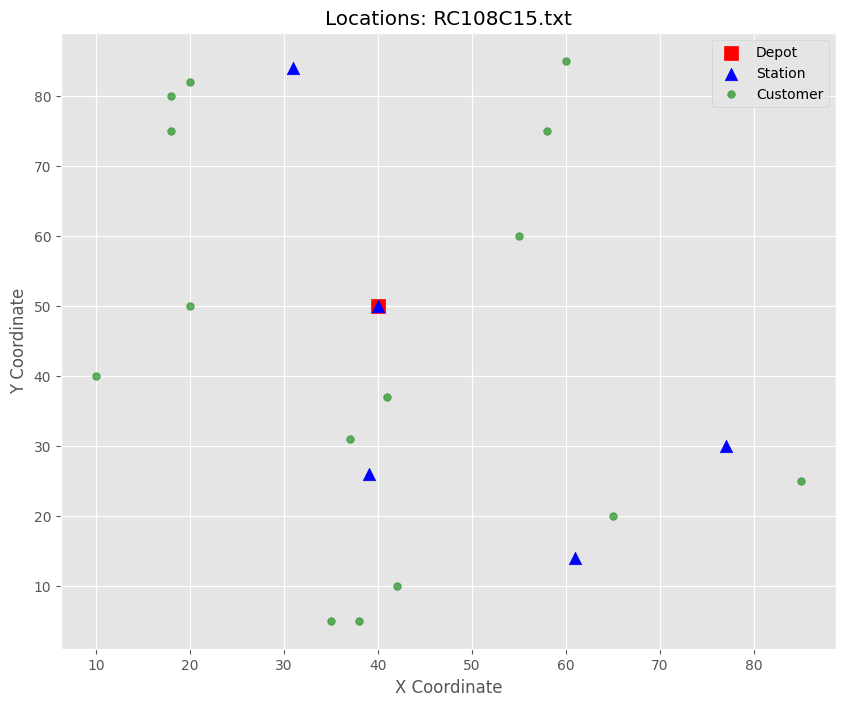

In [3]:
def plot_locations(df, title="Solomon Instance Map"):
    plt.figure(figsize=(10, 8))
    
    # Plot Depot
    depot = df[df['Type'] == 'd']
    plt.scatter(depot['x'], depot['y'], c='red', marker='s', s=100, label='Depot')
    
    # Plot Stations
    stations = df[df['Type'] == 'f']
    plt.scatter(stations['x'], stations['y'], c='blue', marker='^', s=80, label='Station')
    
    # Plot Customers
    customers = df[df['Type'] == 'c']
    plt.scatter(customers['x'], customers['y'], c='green', marker='o', s=30, alpha=0.6, label='Customer')
    
    plt.title(title)
    plt.xlabel("X Coordinate")
    plt.ylabel("Y Coordinate")
    plt.legend()
    plt.grid(True)
    plt.show()

plot_locations(df, f"Locations: {os.path.basename(sample_file)}")

✅ Found solution log: cmake-build-release/logs\RC108C15\RC108C15_front_details.txt
   Parsed 24 routes.


C:\Users\ASUS\AppData\Local\Temp\ipykernel_19220\3576783381.py:100: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap('tab10', len(routes))


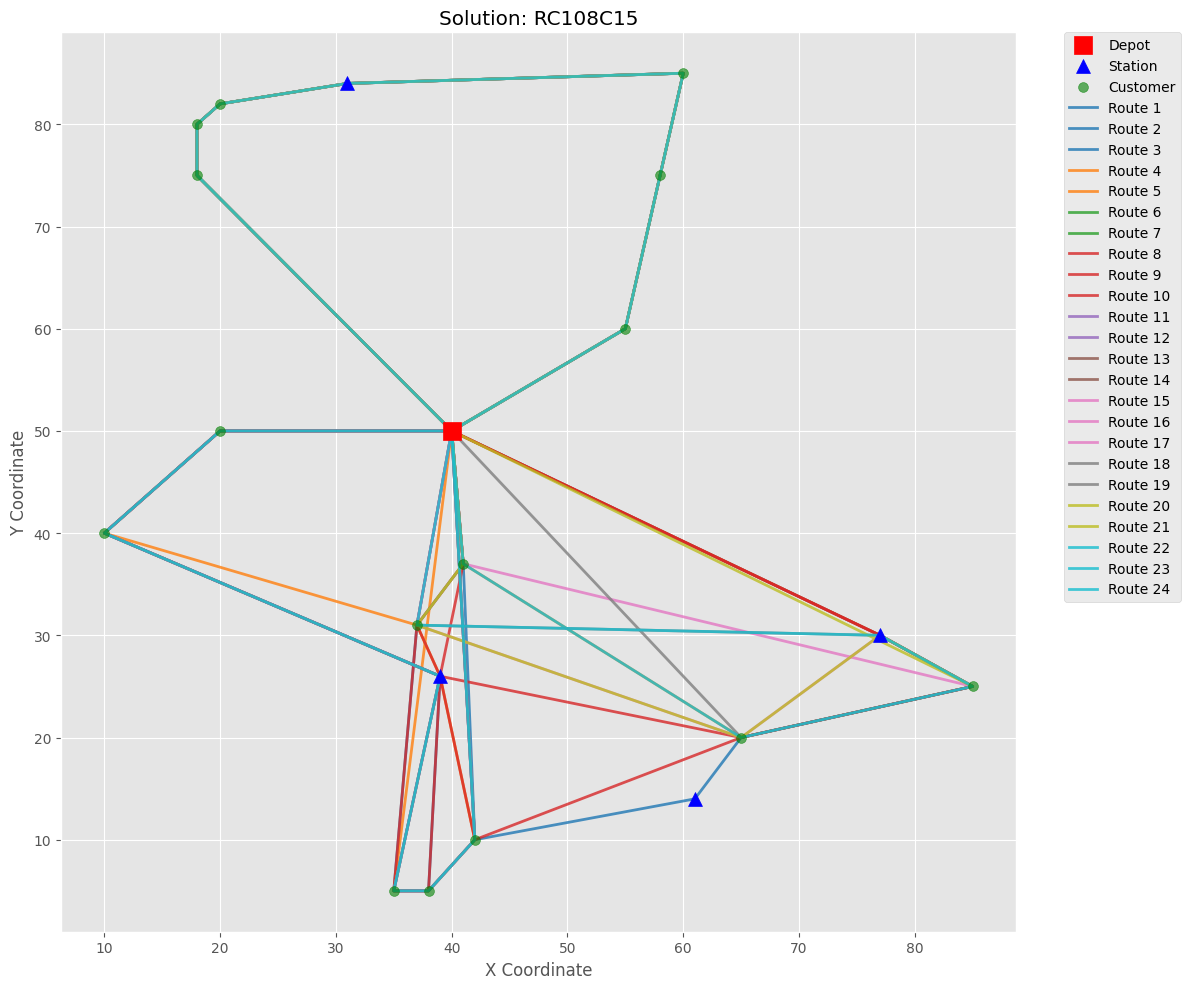

In [4]:
import os
import matplotlib.pyplot as plt
import numpy as np

def parse_solution_log(log_path):
    """
    Hàm phân tích file log chi tiết (format bảng) để lấy danh sách các route.
    Format mong đợi:
    --- Route ID: 2 --- ...
       ...
    --- Node Sequence (Count: 6) ---
      Idx | StrID |       Type ...
    --------------------------------...
        0 |    D0 |      Depot ...
       20 |   C66 |   Customer ...
        0 |    D0 |      Depot ...
    """
    routes = []
    current_route = []
    parsing_sequence = False
    
    try:
        with open(log_path, 'r') as f:
            lines = f.readlines()
            
        for line in lines:
            line = line.strip()
            
            # 1. Phát hiện bắt đầu một Sequence mới
            if "--- Node Sequence" in line:
                # Nếu đang parse dở route trước (dù hiếm khi xảy ra nếu log chuẩn), lưu lại
                if current_route:
                    routes.append(current_route)
                    current_route = []
                parsing_sequence = True
                continue
            
            # 2. Xử lý khi đang trong block Sequence
            if parsing_sequence:
                # Bỏ qua dòng tiêu đề bảng và dòng gạch ngang
                if "Idx | StrID" in line or "-------" in line:
                    continue
                
                # Nếu gặp dòng trống hoặc block khác -> kết thúc route hiện tại
                if not line or line.startswith("===") or line.startswith("---"):
                    if current_route:
                        routes.append(current_route)
                        current_route = []
                    parsing_sequence = False
                    
                    # Nếu dòng này lại bắt đầu một cái gì đó quan trọng (vd Route mới), 
                    # vòng lặp sau sẽ tự xử lý, nhưng ở đây ta set False là an toàn.
                    continue
                
                # 3. Parse dòng dữ liệu: "0 | D0 | Depot | ..."
                parts = line.split('|')
                if len(parts) > 1:
                    try:
                        # Cột đầu tiên là Idx (Node ID trong code C++)
                        node_id = int(parts[0].strip())
                        current_route.append(node_id)
                    except ValueError:
                        pass
        
        # Lưu route cuối cùng nếu còn
        if current_route:
            routes.append(current_route)
            
        return routes

    except FileNotFoundError:
        print(f"Log file not found: {log_path}")
        return []

def plot_solution(df, routes, title="Solution Routes"):
    """
    Vẽ các Route chồng lên bản đồ Customer/Station/Depot
    """
    if df.empty:
        print("DataFrame is empty, cannot plot.")
        return

    plt.figure(figsize=(12, 10))
    
    # 1. Vẽ các điểm cơ bản (Base Locations)
    # Depot
    depot = df[df['Type'] == 'd']
    plt.scatter(depot['x'], depot['y'], c='red', marker='s', s=150, label='Depot', zorder=5)
    
    # Stations
    stations = df[df['Type'] == 'f']
    plt.scatter(stations['x'], stations['y'], c='blue', marker='^', s=100, label='Station', zorder=4)
    
    # Customers
    customers = df[df['Type'] == 'c']
    plt.scatter(customers['x'], customers['y'], c='green', marker='o', s=50, alpha=0.6, label='Customer', zorder=3)

    # 2. Vẽ Routes
    # Tạo bảng màu
    colors = plt.cm.get_cmap('tab10', len(routes))
    
    for i, route_nodes in enumerate(routes):
        route_x = []
        route_y = []
        
        for node_id in route_nodes:
            # Lấy tọa độ từ DataFrame. 
            # Giả sử index của df khớp với Node ID 
            # (Lưu ý: trong log C++, Idx 0 là Depot, các Idx khác khớp với thứ tự load)
            if node_id < len(df):
                row = df.iloc[node_id]
                route_x.append(row['x'])
                route_y.append(row['y'])
        
        # Vẽ đường nối
        plt.plot(route_x, route_y, color=colors(i), linewidth=2, alpha=0.8, label=f'Route {i+1}')
        
        # Vẽ mũi tên đơn giản ở giữa các đoạn (optional, để code đơn giản ta bỏ qua arrow phức tạp)

    plt.title(title)
    plt.xlabel("X Coordinate")
    plt.ylabel("Y Coordinate")
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)
    plt.grid(True)
    plt.tight_layout()
    plt.show()

# --- CHẠY THỬ VỚI LOG CỤ THỂ ---
try:
    instance_name = os.path.basename(sample_file).split('.')[0]
    # Đường dẫn log (lưu ý chữ hoa/thường tùy thuộc hệ thống file)
    # Cấu trúc: cmake-build-release/logs/TÊN_FOLDER/tên_file_front_details.txt
    # Thường tên folder viết hoa trong Solomon dataset (VD: RC108C15)
    
    instance_folder = instance_name.upper() # VD: rc108c15 -> RC108C15 (hoặc giữ nguyên nếu tên folder là thường)
    # Cần check thực tế folder tên gì. Thường data Solomon folder là chữ hoa.
    # Nhưng CMake tạo log theo biến runName.
    
    # Thử vài pattern đường dẫn phổ biến
    log_dir_base = 'cmake-build-release/logs'
    
    possible_paths = [
        os.path.join(log_dir_base, instance_name, f"{instance_name}_front_details.txt"),           # c101/c101...
        os.path.join(log_dir_base, instance_name.upper(), f"{instance_name.lower()}_front_details.txt"), # RC101/rc101...
        os.path.join(log_dir_base, instance_name.upper(), f"{instance_name}_front_details.txt"),   # RC101/RC101...
    ]
    
    # Thêm các path tương đối/tuyệt đối
    final_paths = []
    base_proj = os.getcwd() # Hoặc đường dẫn cứng nếu cần
    for p in possible_paths:
        final_paths.append(p)
        final_paths.append(os.path.join('..', p))
        final_paths.append(os.path.abspath(os.path.join('d:/Work/SLSCM-LaB/24092025/test15 - Copy', p)))

    found_log = None
    for p in final_paths:
        if os.path.exists(p):
            found_log = p
            break

    if found_log:
        print(f"✅ Found solution log: {found_log}")
        routes = parse_solution_log(found_log)
        print(f"   Parsed {len(routes)} routes.")
        
        if routes:
            plot_solution(df, routes, f"Solution: {instance_name}")
        else:
            print("⚠️ Log file found but parsed 0 routes. Check parser logic.")
    else:
        print(f"❌ Log file not found. Run the solver first.")

except NameError:
    print("⚠️ Variable 'sample_file' or 'df' not defined. Run the earlier cells first.")

## 3. Time Window Analysis: Lunch Breaks & Working Hours

We need to check how restrictve the time windows are relative to standard working hours.

**Assumptions:**
*   Start Time: 0 (or Depot Open Time)
*   Lunch Break: Typically around T=4h to T=5h (e.g., 12:00-13:00 if start at 8:00).
*   Standard Work Day: 8 hours.
*   Overtime Threshold: > 8 hours.
*   Max Work Day: e.g., 10-12 hours.

Let's visualize the `ReadyTime` and `DueDate` distribution.

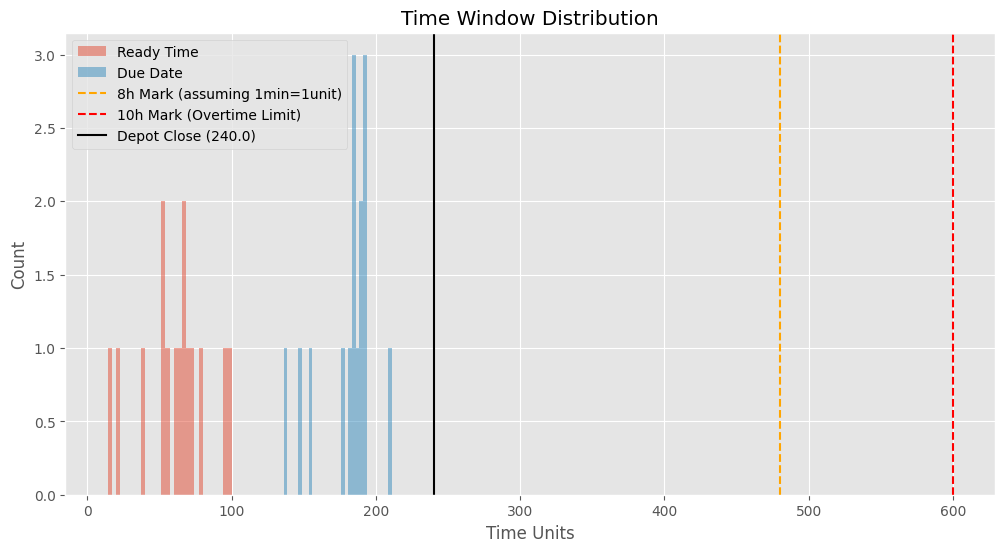

Depot Due Date (Max Horizon): 240.0


In [5]:
customers = df[df['Type'] == 'c'].copy()

plt.figure(figsize=(12, 6))
plt.hist(customers['ReadyTime'], bins=30, alpha=0.5, label='Ready Time')
plt.hist(customers['DueDate'], bins=30, alpha=0.5, label='Due Date')
plt.axvline(x=480, color='orange', linestyle='--', label='8h Mark (assuming 1min=1unit)')
plt.axvline(x=600, color='red', linestyle='--', label='10h Mark (Overtime Limit)')
# Assuming Lunch is around 4h-5h mark (240-300 if 1 unit = 1 min, or scaled differently)
# Need to check 'DueDate' typical values to infer time scale. 
# In Solomon, often 1 unit = 1 minute or arbitrary. Max DueDate is usually the Depot closing time.
depot_due = df[df['Type'] == 'd']['DueDate'].values[0]
plt.axvline(x=depot_due, color='black', linestyle='-', label=f'Depot Close ({depot_due})')

plt.title("Time Window Distribution")
plt.xlabel("Time Units")
plt.ylabel("Count")
plt.legend()
plt.show()

print(f"Depot Due Date (Max Horizon): {depot_due}")

In [6]:
# Lunch Break Feasibility
# Identify customers whose only feasible service time overlaps with Lunch Break
# Assumption: Lunch is 1h, e.g., from T=4*60 to T=5*60 (240 to 300) if Horizon is ~12h (720)
# Adjust based on Depot Due Date.

HORIZON = depot_due
LUNCH_START = HORIZON * (4/10) # Approx 40% into the shift (e.g. 12:00 in a 8:00-18:00 shift)
LUNCH_END = LUNCH_START + 60   # 1 hour break

print(f"Hypothetical Lunch Break: {LUNCH_START:.1f} to {LUNCH_END:.1f}")

def check_lunch_conflict(row):
    # If (ReadyTime > LunchEnd) OR (DueDate < LunchStart), then NO conflict purely based on windows
    # But if the window is fully INSIDE the lunch break, it's impossible without overtime/shift.
    if row['DueDate'] < LUNCH_START:
        return "Before Lunch"
    elif row['ReadyTime'] > LUNCH_END:
        return "After Lunch"
    elif row['ReadyTime'] < LUNCH_START and row['DueDate'] > LUNCH_END:
        return "Flexible (Can fit around)"
    else:
        return "Conflict (Overlap with Lunch)"

customers['LunchStatus'] = customers.apply(check_lunch_conflict, axis=1)
print(customers['LunchStatus'].value_counts())

Hypothetical Lunch Break: 96.0 to 156.0
LunchStatus
Flexible (Can fit around)        10
Conflict (Overlap with Lunch)     5
Name: count, dtype: int64


## 4. Overtime & Working Time Analysis

We can identify "Late" customers who force routes to be long.
If a customer's `ReadyTime` is very late (e.g., > 8h mark), any route serving them *must* involve overtime or a late shift.

Customers requiring service after 480 (Overtime Zone): 0


NameError: name 'depot' is not defined

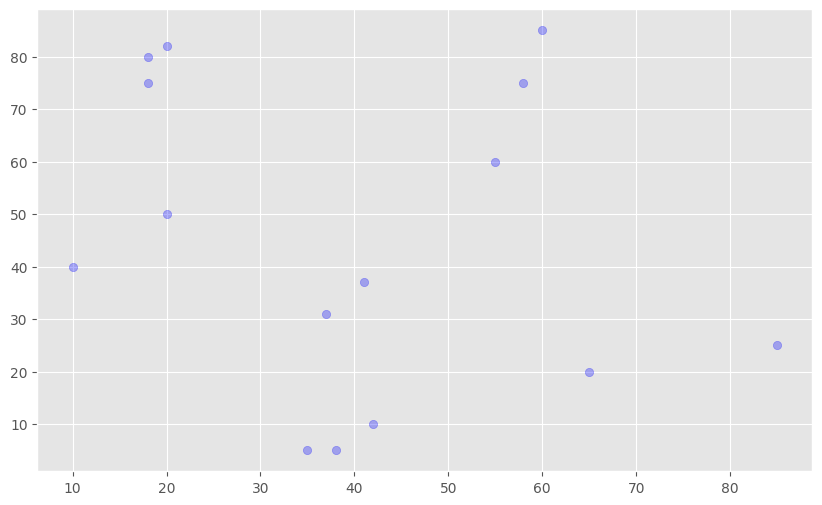

In [7]:
# Define Standard Work Day (e.g., 80% of Horizon or fixed 8h)
STANDARD_WORK_TIME = 480 # 8 hours if unit is min

late_customers = customers[customers['ReadyTime'] > STANDARD_WORK_TIME]
print(f"Customers requiring service after {STANDARD_WORK_TIME} (Overtime Zone): {len(late_customers)}")

plt.figure(figsize=(10, 6))
plt.scatter(customers['x'], customers['y'], c='blue', alpha=0.3, label='Standard Hours')
plt.scatter(late_customers['x'], late_customers['y'], c='red', s=50, label='Late/Overtime Customers')
plt.scatter(depot['x'], depot['y'], c='black', marker='s', s=100, label='Depot')
plt.title("Spatial Distribution of Late Customers")
plt.legend()
plt.show()

## 5. Next Steps for Optimization Logic

Based on this analysis, the EVRP solver should:
1.  **Cost Function**: Add penalty for arrival_time > STANDARD_WORK_TIME (Overtime Cost).
2.  **Constraint**: If `arrival_time` spans across `LUNCH_START` to `LUNCH_END`, push `arrival_time` to `LUNCH_END` (wait) or invalidate if infeasible.
3.  **Vehicle Reduction**: Analyze if extending work hours (Overtime) allows reducing fleet size significanty.